# Generative Modeling from First Principles
### ELBO, Adversarial Games, and Reverse Diffusion

This notebook is a rewrite of the usual "VAE, GAN, and Diffusion from scratch" tour with three rules:

1. **Every figure demonstrates a measurable claim.** No cherry-picked sample strips. If we assert "mode collapse", we *measure* it; if we assert "the closed-form forward diffusion is correct", we *verify* it numerically.
2. **Derive the math, then implement it.** The ELBO, the optimal GAN discriminator, the score/noise equivalence, and the DDPM forward/reverse equations are derived, not asserted.
3. **Stay beginner-accessible.** Intuition is kept, but it is always cashed out into an equation or an experiment.

**Runtime.** All *image* models are small MLPs on MNIST resized to **8×8** (`QUICK=True`, laptop CPU smoke test) or **32×32** (`QUICK=False`, readable digits). Data comes from `torchvision` MNIST when available, else `sklearn`'s `load_digits` (offline, native 8×8).

**Google Colab.** Open this notebook from GitHub (see repo README), choose **Runtime → Change runtime type → GPU**, then **Run all**. On a fresh runtime you may need `!pip install -q scikit-learn scipy` once.

***
### Structure
- **Part 0** — One unifying framework: what object are we actually learning?
- **Part 1** — VAE: intractable MLE → ELBO derivation → latent-space diagnostics → the *exact* reason L2 decoders blur.
- **Part 2** — GAN: minimax → optimal discriminator → JS divergence → collapse & instability *measured*.
- **Part 3** — Denoising score matching: predicting noise ≈ learning $\nabla_x \log p(x)$.
- **Part 4** — DDPM: forward/reverse derived from first principles, verified, sampled (ancestral + DDIM).
- **Part 5** — Comparing objectives quantitatively (class-entropy + a Fréchet feature distance) + the modern diffusion family.
- **Appendix** — Common misconceptions, each linked to the cell that debunks it.

In [12]:
import math, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 0
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# QUICK=True  -> 8x8 digits + fewer steps (CPU smoke test, ~minutes)
# QUICK=False -> 32x32 digits (readable; fine on Colab GPU or patient CPU)
QUICK = False
IMG = 8 if QUICK else 32
print("device:", device, "| QUICK:", QUICK, "| IMG:", IMG, "| torch:", torch.__version__)

device: mps | QUICK: False | torch: 2.9.1


data: torchvision MNIST (resized to 32x32) | shape: (60000, 1, 32, 32) | classes: 10


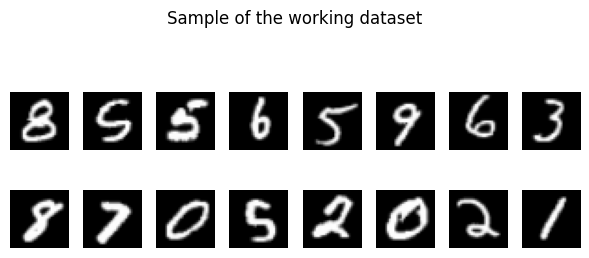

In [15]:
DIM = IMG * IMG  # IMG set in previous cell (8 if QUICK else 32)

def load_digit_images(img=IMG):
    """Return X in [0,1] shape (N,1,img,img), labels y, and a source string.

    Tries torchvision MNIST (downloads once). Falls back to sklearn load_digits,
    which ships with the library and needs no network.
    """
    try:
        from torchvision import datasets, transforms
        ds = datasets.MNIST(root="./data", train=True, download=True)
        X = ds.data.float().unsqueeze(1) / 255.0          # (60000,1,28,28)
        y = ds.targets.clone()
        source = "torchvision MNIST (resized to %dx%d)" % (img, img)
    except Exception:
        from sklearn.datasets import load_digits
        d = load_digits()
        X = torch.tensor(d.images, dtype=torch.float32).unsqueeze(1) / 16.0  # (1797,1,8,8)
        y = torch.tensor(d.target, dtype=torch.long)
        source = "sklearn load_digits (offline fallback)"
    if X.shape[-1] != img:
        X = F.interpolate(X, size=(img, img), mode="bilinear", align_corners=False)
    X = X.clamp(0, 1)
    return X, y, source

X_all, y_all, DATA_SOURCE = load_digit_images()
N_MAX = 6000 if QUICK else len(X_all)
perm = torch.randperm(len(X_all))[:N_MAX]
X_all, y_all = X_all[perm].to(device), y_all[perm].to(device)
print("data:", DATA_SOURCE, "| shape:", tuple(X_all.shape), "| classes:", int(y_all.max()) + 1)

def show_grid(imgs, nrow=8, title=None, figsize=(6, 3)):
    """imgs: (N,1,IMG,IMG) or (N,DIM) tensor in [0,1]."""
    imgs = imgs.detach().cpu().reshape(-1, IMG, IMG)
    n = imgs.shape[0]; ncol = nrow; nrows = math.ceil(n / ncol)
    fig, ax = plt.subplots(nrows, ncol, figsize=figsize)
    ax = np.array(ax).reshape(-1)
    for i in range(len(ax)):
        ax[i].axis("off")
        if i < n:
            ax[i].imshow(imgs[i], cmap="gray", vmin=0, vmax=1)
    if title: fig.suptitle(title)
    plt.tight_layout(); plt.show()

show_grid(X_all[:16], nrow=8, title="Sample of the working dataset")

## Part 0 — One unifying framework

A common opening line is *"all generative models map noise to data."* That is true but lossy: it flattens distinctions that matter the moment you try to train or evaluate these models.

The object we actually want is a distribution over data,

$$p_\theta(x) \approx p_{\text{data}}(x),$$

and the three families differ in **what they commit to modeling**:

| Model | What it learns | Likelihood $p_\theta(x)$? | Sampling |
|---|---|---|---|
| **VAE** | a latent-variable *likelihood* model $p_\theta(x\mid z)p(z)$ | tractable **lower bound** (ELBO) | ancestral: $z\sim p(z),\; x\sim p_\theta(x\mid z)$ |
| **GAN** | an *implicit* sampler $G_\theta(z)$ | **undefined** (no density) | one forward pass $x=G_\theta(z)$ |
| **DDPM** | the transitions of a *reverse stochastic process* | tractable **lower bound** (also an ELBO!) | iterative denoising, $T$ steps |

Why the distinction matters in practice:

- The VAE decoder defines an explicit likelihood $p_\theta(x\mid z)$, so its failure modes are *likelihood* failure modes (e.g. a Gaussian likelihood forces the decoder toward a conditional **mean** — Part 1.4).
- A GAN defines **no** density. You cannot ask "what is $p_\theta(x)$?"; you can only sample. This is exactly why we must evaluate it with sample-based metrics (Part 2.2, Part 5).
- A DDPM commits to a *Markov chain*. Its training target and its samplers (ancestral vs DDIM, Part 4) are consequences of that chain, not of a single "noise→image" map.

Interestingly, VAE and DDPM both optimize an ELBO — a DDPM is, formally, a deep hierarchical VAE with a *fixed* (non-learned) encoder (the forward noising process). We'll see the shared skeleton by Part 4.

## Part 1 — VAE

### 1.1 Why maximum likelihood becomes intractable

We posit a latent-variable model: a prior $p(z)=\mathcal N(0,I)$ and a decoder $p_\theta(x\mid z)$. The marginal likelihood of a datapoint is

$$p_\theta(x)=\int p_\theta(x\mid z)\,p(z)\,dz .$$

To do maximum likelihood we would maximize $\sum_x \log p_\theta(x)$, but the integral is intractable:

- $z$ is continuous and high-dimensional, so there is no closed form for a neural $p_\theta(x\mid z)$.
- A naive Monte Carlo estimate $p_\theta(x)\approx \frac1S\sum_s p_\theta(x\mid z^{(s)}),\ z^{(s)}\sim p(z)$ has catastrophic variance: for almost every prior sample $z^{(s)}$, $p_\theta(x\mid z^{(s)})\approx 0$. The posterior $p_\theta(z\mid x)$ is concentrated on a tiny region of latent space that prior samples essentially never hit.

So we need to (a) avoid the integral and (b) sample $z$ from something close to the *posterior*. Both are solved by variational inference.

### 1.2 Deriving the ELBO

Introduce an **approximate posterior** $q_\phi(z\mid x)$ (the "encoder"). For *any* such $q_\phi$ we can decompose the log-likelihood exactly. Start from the definition and multiply/divide by $q_\phi$:

$$
\log p_\theta(x)
= \log \int p_\theta(x,z)\,dz
= \log \int q_\phi(z\mid x)\,\frac{p_\theta(x,z)}{q_\phi(z\mid x)}\,dz
= \log\, \mathbb E_{q_\phi}\!\left[\frac{p_\theta(x,z)}{q_\phi(z\mid x)}\right].
$$

**Exact identity (no inequality yet).** Because $\log p_\theta(x)$ does not depend on $z$,

$$
\log p_\theta(x)
= \mathbb E_{q_\phi}\big[\log p_\theta(x)\big]
= \mathbb E_{q_\phi}\!\left[\log \frac{p_\theta(x,z)}{q_\phi(z\mid x)}\right]
+ \mathbb E_{q_\phi}\!\left[\log \frac{q_\phi(z\mid x)}{p_\theta(z\mid x)}\right],
$$

where we used $p_\theta(x,z)=p_\theta(z\mid x)\,p_\theta(x)$. The two terms are

$$
\boxed{\;\log p_\theta(x) = \underbrace{\mathbb E_{q_\phi}\!\left[\log \frac{p_\theta(x,z)}{q_\phi(z\mid x)}\right]}_{\textstyle \mathcal L(x)\ \text{(ELBO)}} \;+\; \underbrace{D_{\mathrm{KL}}\!\big(q_\phi(z\mid x)\,\|\,p_\theta(z\mid x)\big)}_{\textstyle \ge 0}\;}
$$

Since KL $\ge 0$, $\mathcal L(x)\le \log p_\theta(x)$ — hence **Evidence Lower BOund**. The gap is exactly how wrong our approximate posterior is. Maximizing $\mathcal L$ simultaneously (i) pushes up a lower bound on the data likelihood and (ii) pulls $q_\phi$ toward the true posterior.

**Rewriting into the trainable form.** Split $p_\theta(x,z)=p_\theta(x\mid z)p(z)$:

$$
\mathcal L(x)
= \mathbb E_{q_\phi}\big[\log p_\theta(x\mid z)\big]
- \underbrace{\mathbb E_{q_\phi}\!\left[\log \frac{q_\phi(z\mid x)}{p(z)}\right]}_{D_{\mathrm{KL}}(q_\phi(z\mid x)\,\|\,p(z))}
= \boxed{\;\mathbb E_{q_\phi}\big[\log p_\theta(x\mid z)\big] - D_{\mathrm{KL}}\!\big(q_\phi(z\mid x)\,\|\,p(z)\big)\;}
$$

- **Term 1** (reconstruction): decode $z\sim q_\phi(z\mid x)$ and score the data. This is where the *choice of likelihood* bites (Part 1.4).
- **Term 2** (rate / regularizer): keep the per-example posterior near the prior. With $q_\phi=\mathcal N(\mu,\mathrm{diag}(\sigma^2))$ and $p=\mathcal N(0,I)$ this KL is closed-form: $\tfrac12\sum_j(\mu_j^2+\sigma_j^2-\log\sigma_j^2-1)$.

**Reparameterization.** Term 1 is an expectation over $q_\phi$, whose parameters we differentiate. Writing $z=\mu_\phi(x)+\sigma_\phi(x)\odot\epsilon,\ \epsilon\sim\mathcal N(0,I)$ moves the randomness off the parameters so $\nabla_\phi$ can pass through the sample (a low-variance pathwise gradient instead of a high-variance score-function estimator).

In [16]:
class VAE(nn.Module):
    def __init__(self, dim=DIM, zdim=2, hidden=256):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(dim, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU())
        self.mu = nn.Linear(hidden, zdim)
        self.logvar = nn.Linear(hidden, zdim)
        self.dec = nn.Sequential(nn.Linear(zdim, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, dim))  # Bernoulli logits

    def encode(self, x):
        h = self.enc(x); return self.mu(h), self.logvar(h)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        return self.dec(z)  # logits

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss(logits, x, mu, logvar):
    # Reconstruction term: Bernoulli log-likelihood (per-pixel). We MAXIMIZE the
    # ELBO, i.e. minimize (-recon_ll + KL).
    recon = F.binary_cross_entropy_with_logits(logits, x, reduction="none").sum(1)
    kl = 0.5 * (mu.pow(2) + logvar.exp() - logvar - 1).sum(1)
    return (recon + kl).mean(), recon.mean(), kl.mean()

torch.manual_seed(SEED)
Xflat = X_all.reshape(len(X_all), -1)
vae = VAE(zdim=2).to(device)
opt = torch.optim.Adam(vae.parameters(), lr=1e-3)
epochs = 40 if QUICK else 120
bs = 256
hist = {"elbo": [], "recon": [], "kl": []}
for ep in range(epochs):
    idx = torch.randperm(len(Xflat))
    tot = [0.0, 0.0, 0.0]
    for i in range(0, len(Xflat), bs):
        xb = Xflat[idx[i:i+bs]]
        logits, mu, logvar = vae(xb)
        loss, rec, kl = vae_loss(logits, xb, mu, logvar)
        opt.zero_grad(); loss.backward(); opt.step()
        tot[0] += loss.item()*len(xb); tot[1] += rec.item()*len(xb); tot[2] += kl.item()*len(xb)
    n = len(Xflat)
    hist["elbo"].append(-tot[0]/n); hist["recon"].append(tot[1]/n); hist["kl"].append(tot[2]/n)
    if (ep+1) % max(1, epochs//5) == 0:
        print(f"epoch {ep+1:3d} | -ELBO {tot[0]/n:7.2f} | recon {tot[1]/n:7.2f} | KL {tot[2]/n:6.3f}")

epoch  24 | -ELBO  193.90 | recon  187.29 | KL  6.614
epoch  48 | -ELBO  189.65 | recon  182.76 | KL  6.898
epoch  72 | -ELBO  187.37 | recon  180.32 | KL  7.052
epoch  96 | -ELBO  186.06 | recon  178.90 | KL  7.159
epoch 120 | -ELBO  185.16 | recon  177.93 | KL  7.233


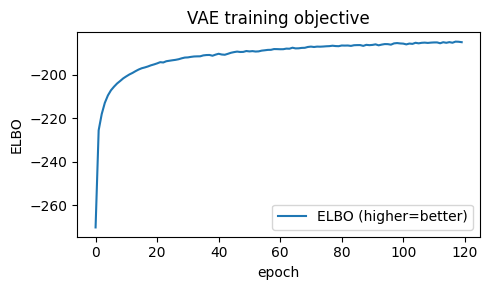

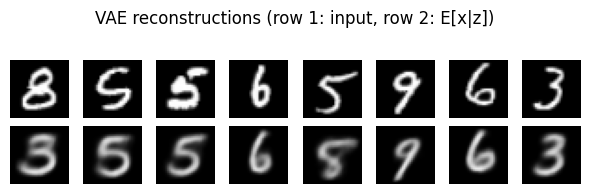

In [17]:
# Measurable claim: training increases the ELBO (our objective) monotonically-ish.
plt.figure(figsize=(5,3))
plt.plot(hist["elbo"], label="ELBO (higher=better)")
plt.xlabel("epoch"); plt.ylabel("ELBO"); plt.title("VAE training objective"); plt.legend()
plt.tight_layout(); plt.show()

# Reconstructions: top=input, bottom=reconstruction mean sigmoid(logits).
vae.eval()
with torch.no_grad():
    xb = Xflat[:8]
    logits, mu, logvar = vae(xb)
    recon = torch.sigmoid(logits)
pair = torch.cat([xb, recon], 0)
show_grid(pair, nrow=8, title="VAE reconstructions (row 1: input, row 2: E[x|z])", figsize=(6,2))

### 1.3 Making "KL regularization" *visible*

Textbooks say the KL term "keeps latent space nice" and warns about "holes" (regions of the prior that the model never mapped real data to). With a 2D latent we can *see* both. We measure three things:

1. **Per-example posteriors** $q_\phi(z\mid x)$ — a scatter of $\mu_\phi(x)$ colored by class.
2. **Aggregated posterior** $q_\phi(z)=\frac1N\sum_x q_\phi(z\mid x)$ vs the prior $\mathcal N(0,I)$. The ELBO only regularizes each posterior *individually*; there is no guarantee the *aggregate* matches the prior. Mismatch ⇒ sampling from $p(z)$ lands in low-density regions.
3. **Holes**: decode a grid over latent space and overlay where the aggregated posterior actually has mass. Grid points far from that mass are "holes" — the prior samples them, but the model never trained there, so decodes are garbage/blurry.

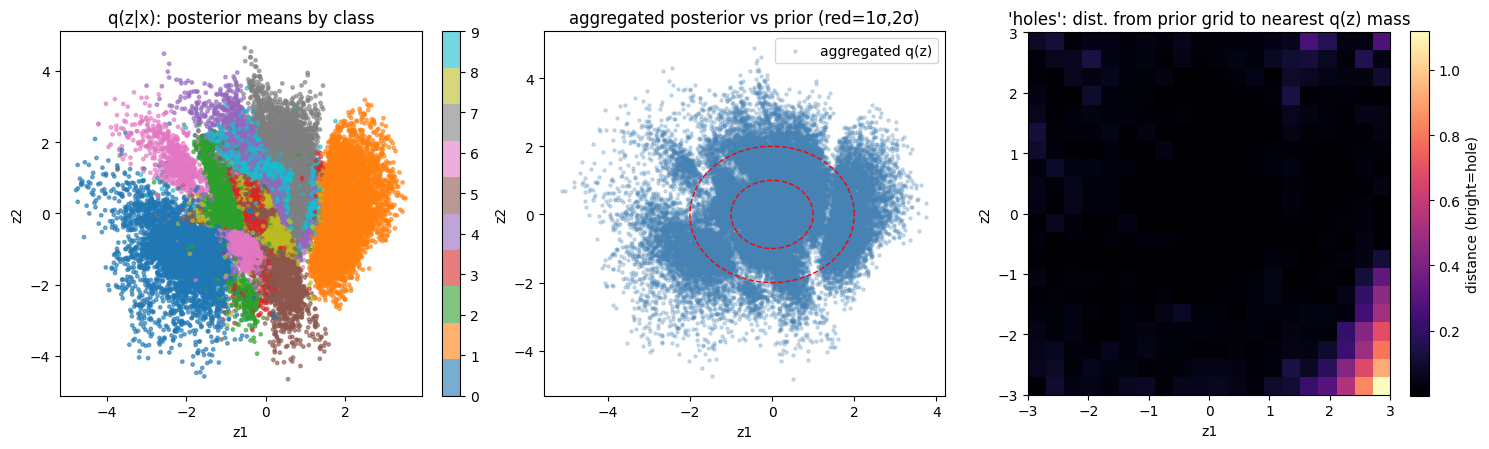

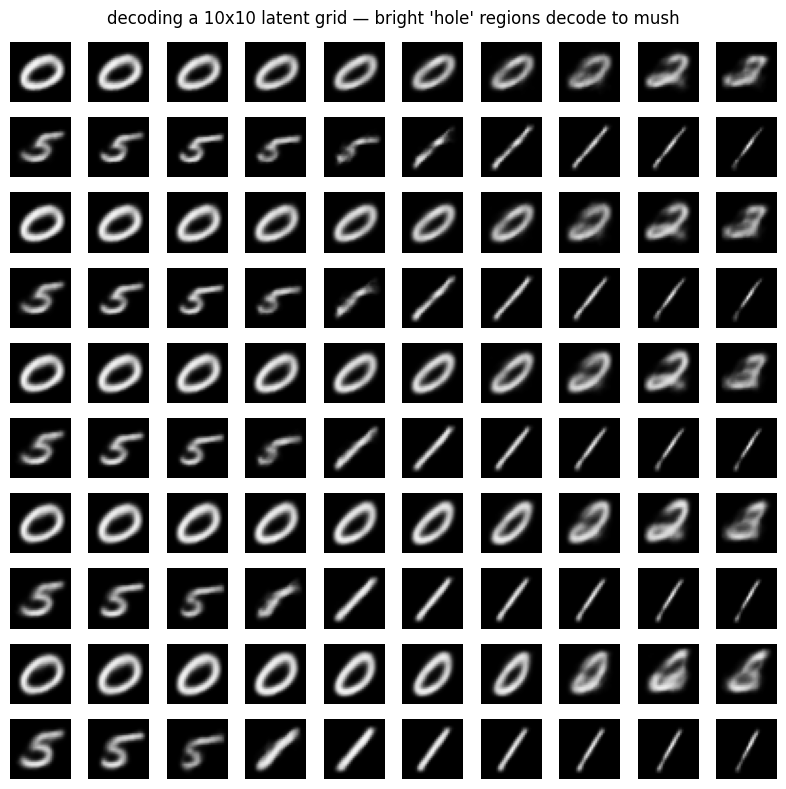

Fraction of prior grid points >0.5 from any real latent (holes): 0.02


In [18]:
vae.eval()
with torch.no_grad():
    mu_all, logvar_all = vae.encode(Xflat)
    mu_np = mu_all.cpu().numpy(); y_np = y_all.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

# (1) per-example posterior means, colored by class
sc = axes[0].scatter(mu_np[:,0], mu_np[:,1], c=y_np, cmap="tab10", s=6, alpha=0.6)
axes[0].set_title("q(z|x): posterior means by class"); axes[0].set_xlabel("z1"); axes[0].set_ylabel("z2")
plt.colorbar(sc, ax=axes[0], fraction=0.046)

# (2) aggregated posterior vs prior. Draw one z per example from q(z|x).
with torch.no_grad():
    z_agg = vae.reparam(mu_all, logvar_all).cpu().numpy()
axes[1].scatter(z_agg[:,0], z_agg[:,1], s=5, alpha=0.25, color="steelblue", label="aggregated q(z)")
th = np.linspace(0, 2*np.pi, 200)
for r in (1, 2):  # prior N(0,I): 1σ, 2σ circles
    axes[1].plot(r*np.cos(th), r*np.sin(th), "r--", lw=1)
axes[1].set_title("aggregated posterior vs prior (red=1σ,2σ)"); axes[1].set_xlabel("z1"); axes[1].set_ylabel("z2")
axes[1].legend(loc="upper right")

# (3) holes: decode a grid; shade grid cells that lie far from aggregated posterior mass.
g = 20; lim = 3.0
gx = np.linspace(-lim, lim, g); gy = np.linspace(-lim, lim, g)
from scipy.spatial import cKDTree
tree = cKDTree(z_agg)
GX, GY = np.meshgrid(gx, gy)
grid = np.stack([GX.ravel(), GY.ravel()], 1)
dist, _ = tree.query(grid, k=1)                     # distance to nearest real latent
dist = dist.reshape(g, g)
hm = axes[2].imshow(dist, extent=[-lim, lim, -lim, lim], origin="lower", cmap="magma")
axes[2].set_title("'holes': dist. from prior grid to nearest q(z) mass")
axes[2].set_xlabel("z1"); axes[2].set_ylabel("z2")
plt.colorbar(hm, ax=axes[2], fraction=0.046, label="distance (bright=hole)")
plt.tight_layout(); plt.show()

# Decode the same grid so the holes are also visually obvious.
with torch.no_grad():
    dec = torch.sigmoid(vae.decode(torch.tensor(grid, dtype=torch.float32, device=device)))
show_grid(dec.reshape(g*g, -1)[::1][:100], nrow=10,
          title="decoding a 10x10 latent grid — bright 'hole' regions decode to mush",
          figsize=(8,8))
print("Fraction of prior grid points >0.5 from any real latent (holes):",
      float((dist > 0.5).mean()))

### 1.4 The *exact* reason L2 (Gaussian) decoders blur

The usual claim "L2 loss causes blur" is a symptom, not a mechanism. Here is the mechanism, exactly.

If the decoder uses a Gaussian likelihood with fixed variance, $p_\theta(x\mid z)=\mathcal N\big(x;\, f_\theta(z),\,\sigma^2 I\big)$, then maximizing $\log p_\theta(x\mid z)$ is minimizing $\|x-f_\theta(z)\|^2$ — the L2 objective. The population minimizer of a squared error is a **conditional expectation**:

$$
f^\star(z)=\arg\min_f \ \mathbb E\big[\|x-f(z)\|^2\big] \;=\; \mathbb E[x\mid z].
$$

Now suppose a single code $z$ is consistent with **multiple** distinct plausible images (the true $p(x\mid z)$ is multimodal — e.g. a "4" that could be open- or closed-top). The optimal L2 decoder cannot output "either/or"; it must output the **average of the modes**, $\mathbb E[x\mid z]$, which is a blurry blend of both. Blur is not a numerical artifact — it is the *Bayes-optimal* output of a mean predictor under multimodal uncertainty.

We demonstrate this with a task where we know the ground truth is bimodal, so the blame is unambiguous.

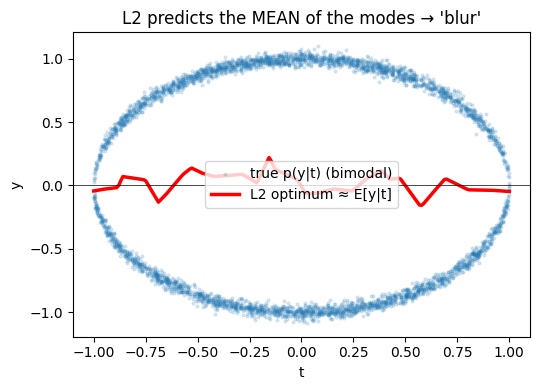

mean |prediction| (dist to mode-average line y=0): 0.061
mean dist from prediction to a real mode:          0.765
The fit hugs the between-modes average, not either mode -> that is the blur, exactly.


In [19]:
# Ground-truth conditional is bimodal: for input t in [-1,1], target y = ±sqrt(1-t^2)
# (points on a circle). So E[y|t]=0 sits BETWEEN the two modes — exactly the "blur".
torch.manual_seed(0)
n = 4000
t = (torch.rand(n,1)*2 - 1)
sign = torch.where(torch.rand(n,1) < 0.5, -1.0, 1.0)
yb = sign * torch.sqrt(torch.clamp(1 - t**2, min=0)) + 0.03*torch.randn(n,1)

reg = nn.Sequential(nn.Linear(1,128), nn.ReLU(), nn.Linear(128,128), nn.ReLU(), nn.Linear(128,1))
o = torch.optim.Adam(reg.parameters(), lr=5e-3)
for _ in range(3000):
    pred = reg(t); loss = F.mse_loss(pred, yb)  # <-- L2 / Gaussian-mean objective
    o.zero_grad(); loss.backward(); o.step()

tt = torch.linspace(-1,1,200).unsqueeze(1)
with torch.no_grad(): pp = reg(tt)
plt.figure(figsize=(5.5,4))
plt.scatter(t.numpy(), yb.numpy(), s=4, alpha=0.15, label="true p(y|t) (bimodal)")
plt.plot(tt.numpy(), pp.numpy(), "r-", lw=2.5, label="L2 optimum ≈ E[y|t]")
plt.axhline(0, color="k", lw=0.5)
plt.title("L2 predicts the MEAN of the modes → 'blur'"); plt.xlabel("t"); plt.ylabel("y"); plt.legend()
plt.tight_layout(); plt.show()

# Quantify: the L2 fit sits near the average of the two modes (~0), not on the data manifold.
with torch.no_grad():
    dist_to_zero = pp.abs().mean().item()
    dist_to_manifold = (pp.squeeze() - torch.sqrt(torch.clamp(1-tt.squeeze()**2,min=0))).abs().mean().item()
print(f"mean |prediction| (dist to mode-average line y=0): {dist_to_zero:.3f}")
print(f"mean dist from prediction to a real mode:          {dist_to_manifold:.3f}")
print("The fit hugs the between-modes average, not either mode -> that is the blur, exactly.")

### 1.5 Escaping blur: a menu of fixes (and VQ-VAE)

Section 1.4 pinned blur on the **Gaussian-mean decoder**: when $p(x\mid z)$ is multimodal, the Bayes-optimal squared-error predictor outputs $\mathbb E[x\mid z]$ — a blend. That is the principled mechanism. (Our digit VAE already uses a Bernoulli pixel likelihood, which avoids the L2↔Gaussian equivalence, but small MLPs on low-res inputs can still look soft for capacity and posterior-hole reasons.)

**Common escape routes:**

| Fix | Idea | Trade-off |
|-----|------|-----------|
| **Different likelihood** | Bernoulli / discretized logistic instead of Gaussian L2 | Still averages if the decoder is effectively unimodal per $z$ |
| **GAN (Part 2)** | No explicit $p_\theta(x)$; discriminator rewards sharp, realistic samples | No density; mode collapse; we'll study this next |
| **$\beta$-VAE / less KL** | Weaken the $\mathcal N(0,I)$ prior pressure | Helps "holes" and oversmoothing from KL, not the multimodal-mean issue by itself |
| **VQ-VAE** | **Discrete** latents: encoder snaps $z$ to nearest codebook vector | No continuous Gaussian KL; decoder learns one map per code — *implemented below* |
| **Diffusion (Part 4)** | Score matching at many noise levels | Sharp samples possible, but many sampling steps |

**VQ-VAE** (van den Oord et al.) replaces $z\in\mathbb R^d$ with a **finite codebook** $\{e_k\}_{k=1}^K$. The encoder outputs $z_e$; we set $z_q = e_{k^\star}$ where $k^\star = \arg\min_k \|z_e - e_k\|$. Training uses a straight-through estimator on $z_q$ and a commitment loss — **no KL on a continuous latent**, so the standard "Gaussian posterior → blur" story does not apply in the same way.

**Caveat:** VQ-VAE does **not** ship with a simple generative prior like $\mathcal N(0,I)$. The original paper learns a separate autoregressive model over codes. Picking **uniform random** codebook indices is a common demo mistake — most entries are never used during training and decode to mush. Below we (i) compare **reconstructions** on the same inputs (the fair sharpness check), and (ii) sample codes from the **empirical marginal** $p(k)$ on training data.

We will look at **GANs** in Part 2.

In [ ]:
class VectorQuantizer(nn.Module):
    """Nearest-neighbor lookup in a learned codebook (straight-through estimator)."""
    def __init__(self, num_embeddings, embedding_dim, beta=0.25):
        super().__init__()
        self.beta = beta
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        nn.init.normal_(self.embedding.weight, mean=0.0, std=1.0 / math.sqrt(embedding_dim))

    def forward(self, z):
        # z: (B, D)
        emb = self.embedding.weight
        dist = (z.pow(2).sum(1, keepdim=True)
                - 2 * z @ emb.t()
                + emb.pow(2).sum(1))
        idx = dist.argmin(1)
        z_q = self.embedding(idx)
        z_q_st = z + (z_q - z).detach()
        vq_loss = F.mse_loss(z_q, z.detach()) + self.beta * F.mse_loss(z_q.detach(), z)
        return z_q_st, vq_loss, idx


class VQVAE(nn.Module):
    def __init__(self, dim=DIM, embed_dim=16, num_embeddings=256, hidden=256):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(dim, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, embed_dim))
        self.quant = VectorQuantizer(num_embeddings, embed_dim)
        self.dec = nn.Sequential(nn.Linear(embed_dim, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, dim))

    def encode(self, x):
        return self.enc(x)

    def decode(self, z):
        return self.dec(z)

    def forward(self, x):
        z_e = self.encode(x)
        z_e = F.normalize(z_e, p=2, dim=-1)
        z_q, vq_loss, idx = self.quant(z_e)
        return self.decode(z_q), vq_loss, idx


def vqvae_loss(logits, x, vq_loss):
    recon = F.binary_cross_entropy_with_logits(logits, x, reduction="none").sum(1).mean()
    return recon + vq_loss, recon, vq_loss

torch.manual_seed(SEED)
vqvae = VQVAE(embed_dim=16, num_embeddings=256).to(device)
opt_vq = torch.optim.Adam(vqvae.parameters(), lr=1e-3)
vq_epochs = epochs  # match VAE training budget
for ep in range(vq_epochs):
    idx = torch.randperm(len(Xflat))
    tot = [0.0, 0.0, 0.0]
    for i in range(0, len(Xflat), bs):
        xb = Xflat[idx[i:i+bs]]
        logits, vq_l, _ = vqvae(xb)
        loss, rec, vq = vqvae_loss(logits, xb, vq_l)
        opt_vq.zero_grad(); loss.backward(); opt_vq.step()
        tot[0] += loss.item() * len(xb); tot[1] += rec.item() * len(xb); tot[2] += vq.item() * len(xb)
    if (ep + 1) % max(1, vq_epochs // 4) == 0:
        n = len(Xflat); r = tot[1]/n/IMG/IMG; v = tot[2]/n
        print(f"VQ epoch {ep+1:3d} | recon {r:.4f}/px | vq {v:.4f} (latent MSE)")

# Fair comparison: reconstructions on the *same* inputs (encode -> decode).
vae.eval(); vqvae.eval()
xb = Xflat[:8]
with torch.no_grad():
    vae_rec = torch.sigmoid(vae(xb)[0])
    vq_rec = torch.sigmoid(vqvae(xb)[0])
show_grid(torch.cat([xb, vae_rec], 0), nrow=8,
          title="VAE recon (row 1: input, row 2: decode(encode(x)))", figsize=(6, 2))
show_grid(torch.cat([xb, vq_rec], 0), nrow=8,
          title="VQ-VAE recon (row 1: input, row 2: decode(quantize(encode(x))))", figsize=(6, 2))

# Generation: VAE z ~ N(0,I); VQ-VAE sample k from empirical p(k) on training data.
with torch.no_grad():
    vae_samp = torch.sigmoid(vae.decode(torch.randn(16, 2, device=device)))
    _, _, codes = vqvae(Xflat)
    K = vqvae.quant.embedding.num_embeddings
    hist_codes = torch.bincount(codes, minlength=K).float()
    probs = hist_codes / hist_codes.sum()
    idx = torch.multinomial(probs, 16, replacement=True)
    vq_samp = torch.sigmoid(vqvae.decode(vqvae.quant.embedding(idx)))

show_grid(vae_samp, nrow=8, title="VAE samples (z ~ N(0,I))", figsize=(8, 2))
show_grid(vq_samp, nrow=8, title="VQ-VAE samples (k ~ empirical p(k) on train)", figsize=(8, 2))
used = (hist_codes > 0).sum().item()
print(f"VQ-VAE used {used}/{K} codebook entries on training data.")

### 1.6 The conv upgrade: spatial latents beat flat MLPs

The linear VQ-VAE above proves the **discrete-latent** idea: once the codebook is initialized at the right scale and actually used, blur from continuous Gaussian averaging largely disappears. The remaining soft edges are mostly a **topology** issue — `nn.Linear` on flattened pixels has no notion of locality.

A **convolutional VQ-VAE** keeps the same `VectorQuantizer`, but the encoder produces a **spatial** latent map $(B, C, H, W)$. Each $H \times W$ location snaps to its own codebook entry, so the decoder can mix local stroke fragments instead of memorizing whole images in one vector. This is the architecture used in the original VQ-VAE paper and in systems like VQ-GAN.

Below we train a minimal `Conv2d` / `ConvTranspose2d` variant on the same data and compare reconstructions to the flat MLP VQ-VAE.

In [ ]:
class ConvVQVAE(nn.Module):
    """VQ-VAE with a spatial latent map: each latent cell covers a patch of the image."""
    def __init__(self, embed_dim=64, num_embeddings=256, hidden=64):
        super().__init__()
        self.embed_dim = embed_dim
        self.enc = nn.Sequential(
            nn.Conv2d(1, hidden, 4, 2, 1), nn.ReLU(),      # 32→16
            nn.Conv2d(hidden, hidden, 4, 2, 1), nn.ReLU(), # 16→8
            nn.Conv2d(hidden, embed_dim, 3, 1, 1),
        )
        self.quant = VectorQuantizer(num_embeddings, embed_dim)
        self.dec = nn.Sequential(
            nn.Conv2d(embed_dim, hidden, 3, 1, 1), nn.ReLU(),
            nn.ConvTranspose2d(hidden, hidden, 4, 2, 1), nn.ReLU(),  # 8→16
            nn.ConvTranspose2d(hidden, 1, 4, 2, 1),                   # 16→32
        )

    def _quantize_spatial(self, z):
        B, C, H, W = z.shape
        z_flat = F.normalize(z.permute(0, 2, 3, 1).reshape(-1, C), p=2, dim=-1)
        z_q, vq_loss, idx = self.quant(z_flat)
        z_q = z_q.reshape(B, H, W, C).permute(0, 3, 1, 2)
        return z_q, vq_loss, idx

    def forward(self, x):
        z_q, vq_loss, idx = self._quantize_spatial(self.enc(x))
        return self.dec(z_q), vq_loss, idx


def conv_vqvae_loss(logits, x, vq_loss):
    recon = F.binary_cross_entropy_with_logits(logits, x, reduction="none").sum((1, 2, 3)).mean()
    return recon + vq_loss, recon, vq_loss

torch.manual_seed(SEED)
conv_vqvae = ConvVQVAE(embed_dim=64, num_embeddings=256).to(device)
opt_conv = torch.optim.Adam(conv_vqvae.parameters(), lr=1e-3)
conv_epochs = max(20, vq_epochs // 2) if QUICK else vq_epochs
for ep in range(conv_epochs):
    idx = torch.randperm(len(X_all))
    tot = [0.0, 0.0, 0.0]
    for i in range(0, len(X_all), bs):
        xb = X_all[idx[i:i+bs]]
        logits, vq_l, _ = conv_vqvae(xb)
        loss, rec, vq = conv_vqvae_loss(logits, xb, vq_l)
        opt_conv.zero_grad(); loss.backward(); opt_conv.step()
        tot[0] += loss.item() * len(xb); tot[1] += rec.item() * len(xb); tot[2] += vq.item() * len(xb)
    if (ep + 1) % max(1, conv_epochs // 4) == 0:
        n = len(X_all); r = tot[1]/n/IMG/IMG; v = tot[2]/n
        print(f"Conv VQ epoch {ep+1:3d} | recon {r:.4f}/px | vq {v:.4f} (latent MSE)")

# Side-by-side reconstructions: flat MLP VQ-VAE vs conv VQ-VAE (same inputs).
vqvae.eval(); conv_vqvae.eval()
xb_img = X_all[:8]
with torch.no_grad():
    mlp_rec = torch.sigmoid(vqvae(xb_img.reshape(8, -1))[0]).reshape_as(xb_img)
    conv_rec = torch.sigmoid(conv_vqvae(xb_img)[0])
show_grid(torch.cat([xb_img, mlp_rec], 0), nrow=8,
          title="Flat VQ-VAE recon (row 1: input, row 2: recon)", figsize=(6, 2))
show_grid(torch.cat([xb_img, conv_rec], 0), nrow=8,
          title="Conv VQ-VAE recon (row 1: input, row 2: recon)", figsize=(6, 2))

## Part 2 — GAN

### 2.1 The minimax game and what it actually optimizes

A GAN pairs a generator $G$ (implicit sampler, $x=G(z),\ z\sim p_z$) with a discriminator $D(x)\in(0,1)$ estimating "probability $x$ is real". The value function is

$$
\min_G \max_D \ V(D,G)= \mathbb E_{x\sim p_{\text{data}}}\big[\log D(x)\big] + \mathbb E_{z\sim p_z}\big[\log(1-D(G(z)))\big].
$$

**Optimal discriminator (for fixed $G$).** Let $p_g$ be the generator's distribution. Then

$$
V = \int p_{\text{data}}(x)\log D(x)\,dx + \int p_g(x)\log(1-D(x))\,dx .
$$

Pointwise, maximize $a\log D + b\log(1-D)$ over $D$: derivative $\tfrac{a}{D}-\tfrac{b}{1-D}=0 \Rightarrow D=\tfrac{a}{a+b}$. Hence

$$
\boxed{\,D^\star(x)=\dfrac{p_{\text{data}}(x)}{p_{\text{data}}(x)+p_g(x)}\,}.
$$

**What $G$ then minimizes.** Substituting $D^\star$ and adding/subtracting $\log 2$:

$$
V(D^\star,G) = -\log 4 + \mathrm{KL}\!\Big(p_{\text{data}}\,\Big\|\,\tfrac{p_{\text{data}}+p_g}{2}\Big) + \mathrm{KL}\!\Big(p_g\,\Big\|\,\tfrac{p_{\text{data}}+p_g}{2}\Big) = -\log 4 + 2\,\mathrm{JS}(p_{\text{data}}\,\|\,p_g).
$$

So at the discriminator's optimum the generator minimizes the **Jensen–Shannon divergence**, with global optimum $p_g=p_{\text{data}}$ (value $-\log 4$). This is far more informative than "forger vs detective": it tells us the *loss geometry*, and it hints at the pathologies — when $p_g$ and $p_{\text{data}}$ have disjoint support, JS is constant ($\log 2$) and gradients vanish; and nothing in the objective forbids $p_g$ from dropping modes (**mode collapse**), because a $G$ that nails a subset of modes can still fool a lagging $D$.

In [7]:
# Toy with KNOWN modes so "collapse" is exactly measurable: 8 Gaussians on a ring.
K = 8; R = 2.0; STD = 0.05
angles = torch.arange(K) * (2*math.pi/K)
MODES = torch.stack([R*torch.cos(angles), R*torch.sin(angles)], 1).to(device)  # (8,2)

def sample_real(n):
    idx = torch.randint(0, K, (n,), device=device)
    return MODES[idx] + STD*torch.randn(n, 2, device=device)

def mode_stats(samples):
    """Assign each sample to nearest mode; return coverage, entropy (nats), counts."""
    d = torch.cdist(samples, MODES)              # (n,8)
    assign = d.argmin(1)
    # only count points reasonably close to a mode as "on a mode"
    near = d.min(1).values < 0.5
    counts = torch.bincount(assign[near], minlength=K).float()
    p = counts / counts.sum().clamp(min=1)
    ent = -(p[p>0] * p[p>0].log()).sum().item()
    coverage = int((counts > 0).sum().item())
    return coverage, ent, counts.cpu().numpy(), near.float().mean().item()

print("max possible entropy (uniform over 8 modes):", math.log(K))

max possible entropy (uniform over 8 modes): 2.0794415416798357


In [8]:
ZD = 2
G = nn.Sequential(nn.Linear(ZD,128), nn.ReLU(), nn.Linear(128,128), nn.ReLU(), nn.Linear(128,2)).to(device)
D = nn.Sequential(nn.Linear(2,128), nn.ReLU(), nn.Linear(128,128), nn.ReLU(), nn.Linear(128,1)).to(device)
optG = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5,0.9))
optD = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5,0.9))
bce = nn.BCEWithLogitsLoss()

def grad_norm(model):
    return math.sqrt(sum((p.grad.detach()**2).sum().item() for p in model.parameters() if p.grad is not None))

iters = 6000 if QUICK else 15000
bs = 256
log = {"dloss": [], "gloss": [], "gnormD": [], "gnormG": [], "entropy": [], "coverage": []}
torch.manual_seed(SEED)
for it in range(iters):
    # --- D step ---
    xr = sample_real(bs)
    z = torch.randn(bs, ZD, device=device)
    xf = G(z).detach()
    optD.zero_grad()
    ld = bce(D(xr), torch.ones(bs,1,device=device)) + bce(D(xf), torch.zeros(bs,1,device=device))
    ld.backward(); gnD = grad_norm(D); optD.step()
    # --- G step (non-saturating) ---
    z = torch.randn(bs, ZD, device=device)
    optG.zero_grad()
    lg = bce(D(G(z)), torch.ones(bs,1,device=device))
    lg.backward(); gnG = grad_norm(G); optG.step()

    if it % 50 == 0:
        with torch.no_grad():
            s = G(torch.randn(2000, ZD, device=device))
        cov, ent, _, _ = mode_stats(s)
        log["dloss"].append(ld.item()); log["gloss"].append(lg.item())
        log["gnormD"].append(gnD); log["gnormG"].append(gnG)
        log["entropy"].append(ent); log["coverage"].append(cov)
print(f"final: coverage {log['coverage'][-1]}/8 modes | entropy {log['entropy'][-1]:.3f} / {math.log(K):.3f}")

final: coverage 8/8 modes | entropy 1.827 / 2.079


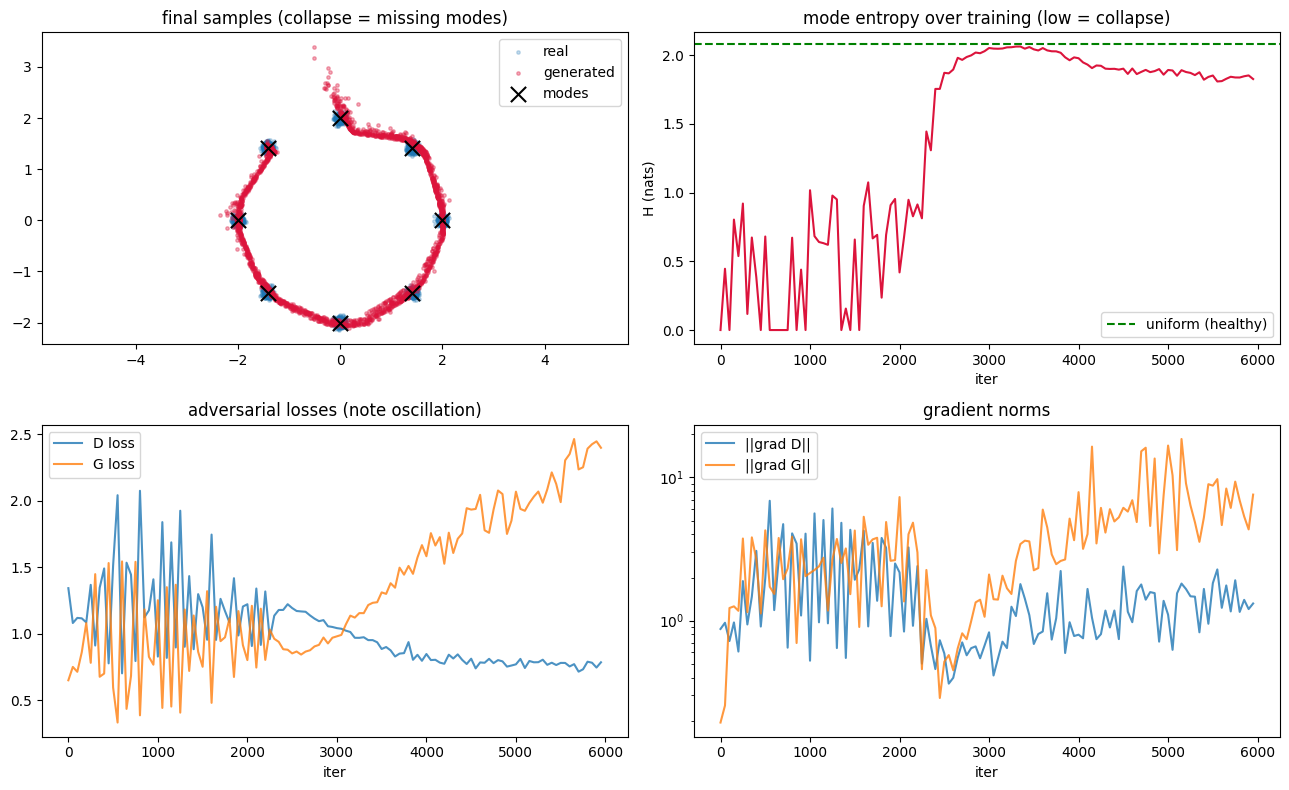

per-mode counts (of 3000): [ 216  276  171 1025  191  192  161  163]
fraction of samples on any mode: 0.80
Collapse is now a NUMBER (entropy, coverage), not a vibe from a sample strip.


In [9]:
xs = np.arange(len(log["entropy"])) * 50
fig, ax = plt.subplots(2, 2, figsize=(13, 8))

# (a) samples vs real modes
with torch.no_grad():
    gen = G(torch.randn(3000, ZD, device=device)).cpu().numpy()
real = sample_real(3000).cpu().numpy()
ax[0,0].scatter(real[:,0], real[:,1], s=6, alpha=0.25, label="real")
ax[0,0].scatter(gen[:,0], gen[:,1], s=6, alpha=0.35, color="crimson", label="generated")
ax[0,0].scatter(MODES.cpu()[:,0], MODES.cpu()[:,1], marker="x", s=120, color="k", label="modes")
ax[0,0].set_title("final samples (collapse = missing modes)"); ax[0,0].legend(); ax[0,0].axis("equal")

# (b) mode entropy over training — the measurable collapse signal
ax[0,1].plot(xs, log["entropy"], color="crimson")
ax[0,1].axhline(math.log(K), ls="--", color="green", label="uniform (healthy)")
ax[0,1].set_title("mode entropy over training (low = collapse)")
ax[0,1].set_xlabel("iter"); ax[0,1].set_ylabel("H (nats)"); ax[0,1].legend()

# (c) losses oscillate — instability is dynamic, not just visual
ax[1,0].plot(xs, log["dloss"], label="D loss", alpha=0.8)
ax[1,0].plot(xs, log["gloss"], label="G loss", alpha=0.8)
ax[1,0].set_title("adversarial losses (note oscillation)"); ax[1,0].set_xlabel("iter"); ax[1,0].legend()

# (d) gradient norms
ax[1,1].plot(xs, log["gnormD"], label="||grad D||", alpha=0.8)
ax[1,1].plot(xs, log["gnormG"], label="||grad G||", alpha=0.8)
ax[1,1].set_title("gradient norms"); ax[1,1].set_xlabel("iter"); ax[1,1].set_yscale("log"); ax[1,1].legend()
plt.tight_layout(); plt.show()

_, _, counts, on_mode = mode_stats(torch.tensor(gen, device=device))
print("per-mode counts (of 3000):", counts.astype(int))
print(f"fraction of samples on any mode: {on_mode:.2f}")
print("Collapse is now a NUMBER (entropy, coverage), not a vibe from a sample strip.")

## Part 3 — Denoising score matching: predicting noise *is* learning the score

Before DDPM, the cleaner idea: learn the **score** $s(x)=\nabla_x \log p(x)$ — the vector field pointing toward higher data density. With the score you can sample by **Langevin dynamics**:

$$
x_{k+1} = x_k + \tfrac{\eta}{2}\,\nabla_x \log p(x_k) + \sqrt{\eta}\,\xi_k,\qquad \xi_k\sim\mathcal N(0,I),
$$

which converges to $p(x)$ as $\eta\to0$, $k\to\infty$.

We can't evaluate $\nabla_x\log p$ (we don't know $p$), but **denoising score matching** (Vincent, 2011) gives a tractable target. Corrupt data with Gaussian noise, $\tilde x = x + \sigma\epsilon,\ \epsilon\sim\mathcal N(0,I)$, so $q_\sigma(\tilde x\mid x)=\mathcal N(\tilde x;x,\sigma^2 I)$. A key identity: the minimizer of the denoising objective equals the score of the *noised* density,

$$
s_\theta^\star(\tilde x)=\nabla_{\tilde x}\log q_\sigma(\tilde x)=\mathbb E\!\left[\frac{x-\tilde x}{\sigma^2}\,\middle|\,\tilde x\right].
$$

Because $\nabla_{\tilde x}\log q_\sigma(\tilde x\mid x) = (x-\tilde x)/\sigma^2 = -\epsilon/\sigma$, training a network to predict the score is *equivalent* to training it to predict the noise $\epsilon$ (up to the $-1/\sigma$ factor):

$$
\underbrace{\mathbb E\big\|\,s_\theta(\tilde x)-\tfrac{x-\tilde x}{\sigma^2}\,\big\|^2}_{\text{score matching}}
\quad\Longleftrightarrow\quad
\underbrace{\mathbb E\big\|\,\epsilon_\theta(\tilde x)-\epsilon\,\big\|^2}_{\text{noise prediction, with } s_\theta=-\epsilon_\theta/\sigma}.
$$

**This is the bridge to diffusion:** the DDPM training loss in Part 4 is exactly noise prediction, i.e. score matching at many noise levels at once.

In [10]:
# 2D data so we can PLOT the learned score field and compare to a sampler.
from sklearn.datasets import make_moons
Xm, _ = make_moons(n_samples=4000, noise=0.07)
Xm = torch.tensor(Xm, dtype=torch.float32)
Xm = (Xm - Xm.mean(0)) / Xm.std(0)          # standardize
Xm = Xm.to(device)

SIGMA = 0.15
score_net = nn.Sequential(nn.Linear(2,128), nn.SiLU(), nn.Linear(128,128), nn.SiLU(), nn.Linear(128,2)).to(device)
opt = torch.optim.Adam(score_net.parameters(), lr=2e-3)
iters = 4000 if QUICK else 8000
for it in range(iters):
    idx = torch.randint(0, len(Xm), (512,), device=device)
    x = Xm[idx]
    eps = torch.randn_like(x)
    xt = x + SIGMA*eps
    target_score = (x - xt) / SIGMA**2          # = -eps/SIGMA
    loss = F.mse_loss(score_net(xt), target_score)
    opt.zero_grad(); loss.backward(); opt.step()
print("final DSM loss:", loss.item())

final DSM loss: 29.1240291595459


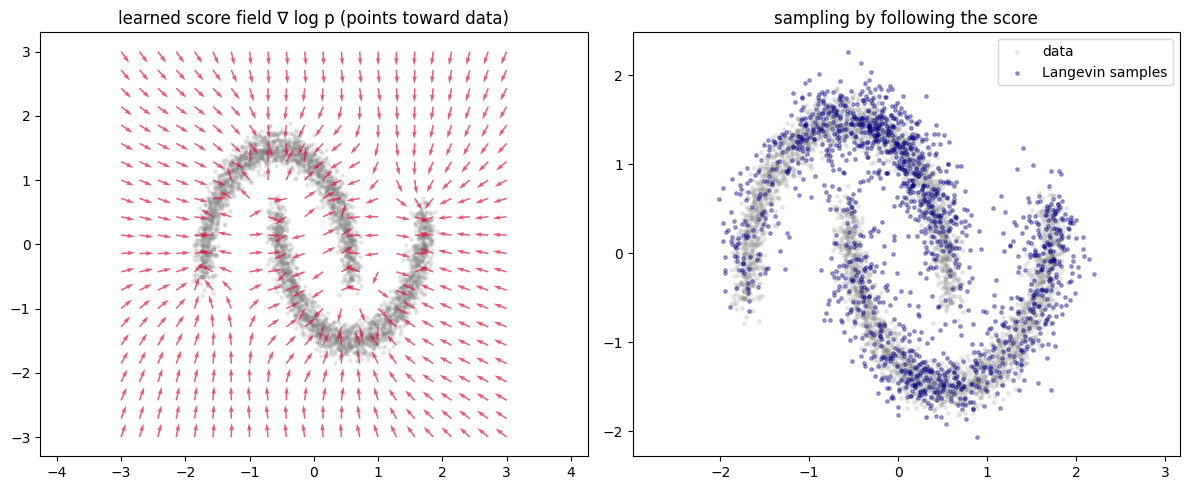

mean dist gen->data: 0.045 | data->data nn: 0.017


In [11]:
# (1) Visualize the learned score field over a grid.
g = 22; lim = 3.0
gx = np.linspace(-lim, lim, g)
GX, GY = np.meshgrid(gx, gx)
grid = torch.tensor(np.stack([GX.ravel(), GY.ravel()],1), dtype=torch.float32, device=device)
with torch.no_grad():
    sc = score_net(grid).cpu().numpy()
sc_n = sc / (np.linalg.norm(sc, axis=1, keepdims=True) + 1e-8)

# (2) Langevin sampling from noise using the learned score.
torch.manual_seed(1)
x = torch.randn(1500, 2, device=device)*1.5
eta = 0.02
for _ in range(800):
    x = x + 0.5*eta*score_net(x).detach() + math.sqrt(eta)*torch.randn_like(x)
xs = x.cpu().numpy()

fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].scatter(Xm.cpu()[:,0], Xm.cpu()[:,1], s=5, alpha=0.15, color="gray")
ax[0].quiver(GX, GY, sc_n[:,0].reshape(g,g), sc_n[:,1].reshape(g,g), color="crimson", alpha=0.7)
ax[0].set_title("learned score field ∇ log p (points toward data)"); ax[0].axis("equal")
ax[1].scatter(Xm.cpu()[:,0], Xm.cpu()[:,1], s=6, alpha=0.15, color="gray", label="data")
ax[1].scatter(xs[:,0], xs[:,1], s=6, alpha=0.35, color="navy", label="Langevin samples")
ax[1].set_title("sampling by following the score"); ax[1].legend(); ax[1].axis("equal")
plt.tight_layout(); plt.show()

# Measurable: samples land on the data manifold. Compare nearest-neighbor distances.
from scipy.spatial import cKDTree
tree = cKDTree(Xm.cpu().numpy())
d_gen,_ = tree.query(xs, k=1)
d_self,_ = tree.query(Xm.cpu().numpy(), k=2)  # self is 0, take 2nd
print(f"mean dist gen->data: {d_gen.mean():.3f} | data->data nn: {d_self[:,1].mean():.3f}")

## Part 4 — DDPM, derived

A DDPM defines a **fixed** forward chain that gradually turns data into noise, then **learns** the reverse chain.

### 4.1 Forward process and its closed form

Forward (variance-preserving) Markov chain with schedule $\beta_1,\dots,\beta_T$:

$$
q(x_t\mid x_{t-1})=\mathcal N\!\big(x_t;\ \sqrt{1-\beta_t}\,x_{t-1},\ \beta_t I\big).
$$

Let $\alpha_t=1-\beta_t$ and $\bar\alpha_t=\prod_{s\le t}\alpha_s$. **Claim (closed form):**

$$
q(x_t\mid x_0)=\mathcal N\!\big(x_t;\ \sqrt{\bar\alpha_t}\,x_0,\ (1-\bar\alpha_t)I\big),\qquad
x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\epsilon,\ \ \epsilon\sim\mathcal N(0,I).
$$

**Derivation (induction).** One step: $x_t=\sqrt{\alpha_t}\,x_{t-1}+\sqrt{1-\alpha_t}\,\epsilon_{t}$. Assume $x_{t-1}=\sqrt{\bar\alpha_{t-1}}x_0+\sqrt{1-\bar\alpha_{t-1}}\,\bar\epsilon_{t-1}$. Substitute:

$$
x_t=\sqrt{\alpha_t\bar\alpha_{t-1}}\,x_0+\underbrace{\sqrt{\alpha_t(1-\bar\alpha_{t-1})}\,\bar\epsilon_{t-1}+\sqrt{1-\alpha_t}\,\epsilon_t}_{\text{sum of independent Gaussians}}.
$$

The noise term is zero-mean Gaussian with variance $\alpha_t(1-\bar\alpha_{t-1})+(1-\alpha_t)=1-\alpha_t\bar\alpha_{t-1}=1-\bar\alpha_t$. And $\alpha_t\bar\alpha_{t-1}=\bar\alpha_t$. So $x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\,\epsilon$. $\blacksquare$

Below we **verify this numerically**: iterating the one-step kernel many times must match the closed form's mean and variance.

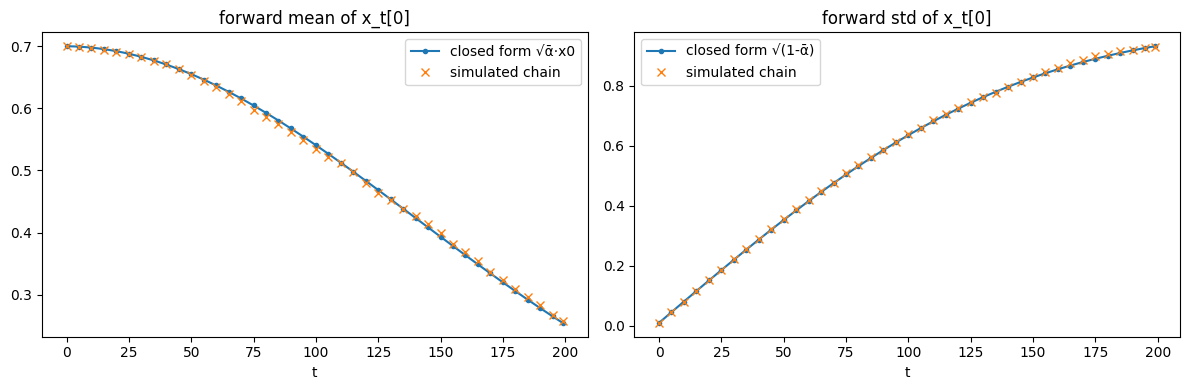

max |mean error|: 0.006610393524169922
max |std  error|: 0.008877594753495033


In [12]:
T = 200 if QUICK else 1000
betas = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1 - betas
abar = torch.cumprod(alphas, 0)

# Numerical verification: simulate the step-by-step chain for a fixed x0 many times,
# then compare empirical mean/std at each t to the closed form.
torch.manual_seed(0)
x0 = torch.tensor([[0.7, -0.4]], device=device)         # a fixed 2D "datapoint"
M = 20000
x = x0.repeat(M, 1)
emp_mean, emp_std, cf_mean, cf_std, ts = [], [], [], [], []
for t in range(T):
    x = torch.sqrt(alphas[t])*x + torch.sqrt(betas[t])*torch.randn_like(x)  # one-step kernel
    if t % max(1, T//40) == 0 or t == T-1:
        ts.append(t)
        emp_mean.append(x.mean(0)[0].item()); emp_std.append(x.std(0)[0].item())
        cf_mean.append((torch.sqrt(abar[t])*x0[0,0]).item())
        cf_std.append(math.sqrt(1 - abar[t].item()))

fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(ts, cf_mean, "o-", label="closed form √ᾱ·x0", ms=3)
ax[0].plot(ts, emp_mean, "x", label="simulated chain", ms=6)
ax[0].set_title("forward mean of x_t[0]"); ax[0].set_xlabel("t"); ax[0].legend()
ax[1].plot(ts, cf_std, "o-", label="closed form √(1-ᾱ)", ms=3)
ax[1].plot(ts, emp_std, "x", label="simulated chain", ms=6)
ax[1].set_title("forward std of x_t[0]"); ax[1].set_xlabel("t"); ax[1].legend()
plt.tight_layout(); plt.show()
print("max |mean error|:", max(abs(a-b) for a,b in zip(emp_mean,cf_mean)))
print("max |std  error|:", max(abs(a-b) for a,b in zip(emp_std, cf_std)))

### 4.2 Why predict the noise? (and the $\epsilon$ / $x_0$ / $v$ equivalence)

Given $x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\,\epsilon$, the three common prediction targets are **deterministically interchangeable** given $(x_t,t)$:

$$
x_0 = \frac{x_t-\sqrt{1-\bar\alpha_t}\,\epsilon}{\sqrt{\bar\alpha_t}},\qquad
\epsilon = \frac{x_t-\sqrt{\bar\alpha_t}\,x_0}{\sqrt{1-\bar\alpha_t}},\qquad
v \equiv \sqrt{\bar\alpha_t}\,\epsilon-\sqrt{1-\bar\alpha_t}\,x_0 .
$$

- **$\epsilon$-prediction** (Ho et al. 2020) is the default: the target has unit variance at every $t$, so the loss is well-scaled across noise levels — a big practical reason it beats predicting $x_0$ directly.
- **$x_0$-prediction** is intuitive but poorly scaled at high noise (target barely constrained).
- **$v$-prediction** (Salimans & Ho 2022) behaves well across the whole schedule (especially near $t\!=\!T$ and for distillation) and is what many modern systems use.

These are *reparameterizations of the same objective*, not different models. We verify the identities numerically.

In [13]:
# Numerically verify eps <-> x0 <-> v are consistent reparameterizations.
torch.manual_seed(0)
t = T//2
x0_ = torch.randn(5, DIM, device=device)
eps_ = torch.randn(5, DIM, device=device)
a = torch.sqrt(abar[t]); b = torch.sqrt(1-abar[t])
xt = a*x0_ + b*eps_

x0_from_eps = (xt - b*eps_) / a
eps_from_x0 = (xt - a*x0_) / b
v = a*eps_ - b*x0_
# recover x0 and eps from (xt, v):  x0 = a*xt - b*v ;  eps = b*xt + a*v
x0_from_v = a*xt - b*v
eps_from_v = b*xt + a*v
print("‖x0 - x0(eps)‖ :", (x0_ - x0_from_eps).abs().max().item())
print("‖eps - eps(x0)‖:", (eps_ - eps_from_x0).abs().max().item())
print("‖x0 - x0(v)‖   :", (x0_ - x0_from_v).abs().max().item())
print("‖eps - eps(v)‖ :", (eps_ - eps_from_v).abs().max().item())
print("All ~0 => the three targets carry identical information given (x_t, t).")

‖x0 - x0(eps)‖ : 2.384185791015625e-07
‖eps - eps(x0)‖: 4.76837158203125e-07
‖x0 - x0(v)‖   : 4.76837158203125e-07
‖eps - eps(v)‖ : 4.76837158203125e-07
All ~0 => the three targets carry identical information given (x_t, t).


### 4.3 Reverse process: why a Gaussian, and its exact mean

We want $p_\theta(x_{t-1}\mid x_t)$. Two facts make a Gaussian reverse principled:

1. When each $\beta_t$ is small, the true reverse conditional $q(x_{t-1}\mid x_t)$ is *approximately Gaussian* (small steps ⇒ locally Gaussian), so $p_\theta(x_{t-1}\mid x_t)=\mathcal N(\mu_\theta,\Sigma_\theta)$ is a good family.
2. The *forward posterior conditioned on $x_0$*, $q(x_{t-1}\mid x_t,x_0)$, is **exactly** Gaussian and gives us the training target. By Bayes with the Gaussians above,

$$
q(x_{t-1}\mid x_t,x_0)=\mathcal N\big(x_{t-1};\ \tilde\mu_t(x_t,x_0),\ \tilde\beta_t I\big),\quad
\tilde\beta_t=\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\beta_t,
$$
$$
\tilde\mu_t(x_t,x_0)=\frac{\sqrt{\bar\alpha_{t-1}}\,\beta_t}{1-\bar\alpha_t}x_0+\frac{\sqrt{\alpha_t}\,(1-\bar\alpha_{t-1})}{1-\bar\alpha_t}x_t .
$$

Substituting $x_0=(x_t-\sqrt{1-\bar\alpha_t}\,\epsilon)/\sqrt{\bar\alpha_t}$ and simplifying gives the sampler's mean in terms of a **noise predictor** $\epsilon_\theta$:

$$
\boxed{\ \mu_\theta(x_t,t)=\frac{1}{\sqrt{\alpha_t}}\Big(x_t-\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\epsilon_\theta(x_t,t)\Big)\ }.
$$

Minimizing the ELBO for this model reduces (dropping $t$-dependent weights, as Ho et al. do) to the beautifully simple

$$
L_{\text{simple}}=\mathbb E_{x_0,\,t,\,\epsilon}\big\|\,\epsilon-\epsilon_\theta(\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon,\ t)\,\big\|^2 .
$$

That is exactly the score-matching / noise-prediction loss from Part 3, applied at all noise levels. We now train it.

step   800 | Lsimple 0.2988


step  1600 | Lsimple 0.2633


step  2400 | Lsimple 0.2493


step  3200 | Lsimple 0.2386


step  4000 | Lsimple 0.2313


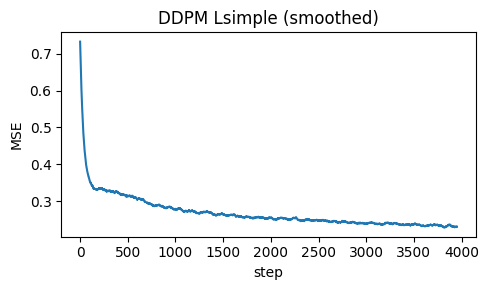

In [14]:
def timestep_embedding(t, dim=32):
    # standard sinusoidal embedding; t is a (B,) long tensor
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half-1))
    a = t.float()[:, None] * freqs[None]
    return torch.cat([torch.sin(a), torch.cos(a)], 1)

class EpsMLP(nn.Module):
    def __init__(self, dim=DIM, temb=32, hidden=256):
        super().__init__()
        self.temb = temb
        self.net = nn.Sequential(
            nn.Linear(dim + temb, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, dim))
    def forward(self, x, t):
        return self.net(torch.cat([x, timestep_embedding(t, self.temb)], 1))

# data scaled to [-1,1] for the VP process
Xd = (X_all.reshape(len(X_all), -1) * 2 - 1)
eps_net = EpsMLP().to(device)
opt = torch.optim.Adam(eps_net.parameters(), lr=2e-3)

def frechet_placeholder():  # defined properly in Part 5; referenced for training curve
    return None

steps = 4000 if QUICK else 12000
bs = 256
losses = []
torch.manual_seed(SEED)
for s in range(steps):
    idx = torch.randint(0, len(Xd), (bs,), device=device)
    x0 = Xd[idx]
    t = torch.randint(0, T, (bs,), device=device)
    eps = torch.randn_like(x0)
    a = torch.sqrt(abar[t]).unsqueeze(1); b = torch.sqrt(1-abar[t]).unsqueeze(1)
    xt = a*x0 + b*eps
    pred = eps_net(xt, t)
    loss = F.mse_loss(pred, eps)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    if (s+1) % max(1, steps//5) == 0:
        print(f"step {s+1:5d} | Lsimple {np.mean(losses[-200:]):.4f}")

plt.figure(figsize=(5,3))
plt.plot(np.convolve(losses, np.ones(50)/50, mode="valid"))
plt.title("DDPM Lsimple (smoothed)"); plt.xlabel("step"); plt.ylabel("MSE"); plt.tight_layout(); plt.show()

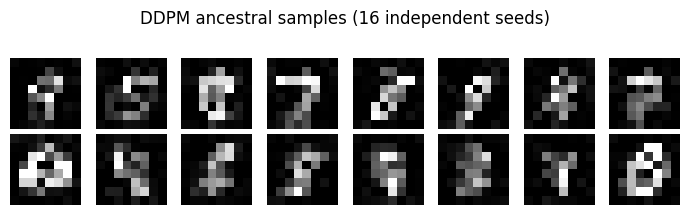

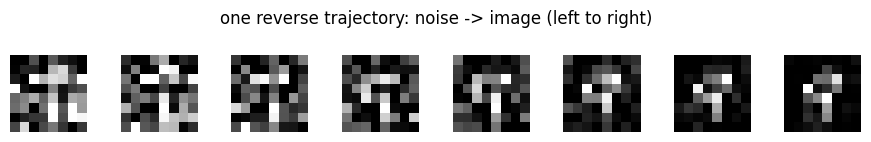

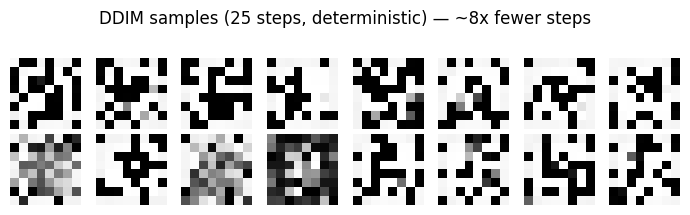

In [15]:
@torch.no_grad()
def ddpm_sample(n, seed=0, keep_traj=False):
    """Ancestral sampler using mu_theta derived in 4.3."""
    g = torch.Generator(device=device).manual_seed(seed)
    x = torch.randn(n, DIM, device=device, generator=g)
    traj = []
    for t in reversed(range(T)):
        tb = torch.full((n,), t, device=device, dtype=torch.long)
        eps = eps_net(x, tb)
        coef = betas[t] / torch.sqrt(1 - abar[t])
        mean = (x - coef*eps) / torch.sqrt(alphas[t])
        if t > 0:
            x = mean + torch.sqrt(betas[t]) * torch.randn(n, DIM, device=device, generator=g)
        else:
            x = mean
        if keep_traj and (t % max(1, T//8) == 0 or t == 0):
            traj.append(((x.clamp(-1,1)+1)/2).clone())
    x = (x.clamp(-1,1)+1)/2
    return (x, traj) if keep_traj else x

@torch.no_grad()
def ddim_sample(n, steps=25, seed=0, eta=0.0):
    """Deterministic (eta=0) DDIM sampler on a subsequence of timesteps."""
    g = torch.Generator(device=device).manual_seed(seed)
    x = torch.randn(n, DIM, device=device, generator=g)
    seq = torch.linspace(0, T-1, steps, device=device).long().tolist()[::-1]
    for i, t in enumerate(seq):
        tb = torch.full((n,), t, device=device, dtype=torch.long)
        eps = eps_net(x, tb)
        at = abar[t]
        x0_pred = (x - torch.sqrt(1-at)*eps) / torch.sqrt(at)
        x0_pred = x0_pred.clamp(-1, 1)
        t_prev = seq[i+1] if i+1 < len(seq) else 0
        ap = abar[t_prev] if t_prev > 0 else torch.tensor(1.0, device=device)
        sigma = eta * torch.sqrt((1-ap)/(1-at) * (1-at/ap)) if t_prev > 0 else torch.tensor(0.0, device=device)
        dir_xt = torch.sqrt(torch.clamp(1-ap-sigma**2, min=0)) * eps
        x = torch.sqrt(ap)*x0_pred + dir_xt
        if t_prev > 0 and eta > 0:
            x = x + sigma*torch.randn(n, DIM, device=device, generator=g)
    return ((x.clamp(-1,1)+1)/2)

samp, traj = ddpm_sample(16, seed=1, keep_traj=True)
show_grid(samp, nrow=8, title="DDPM ancestral samples (16 independent seeds)", figsize=(7,2.2))

# intermediate frames of ONE chain: the denoising trajectory
frames = torch.cat([tr[0:1] for tr in traj], 0)
show_grid(frames, nrow=len(frames), title="one reverse trajectory: noise -> image (left to right)", figsize=(9,1.4))

ddim = ddim_sample(16, steps=25, seed=1)
show_grid(ddim, nrow=8, title="DDIM samples (25 steps, deterministic) — ~8x fewer steps", figsize=(7,2.2))

### 4.4 Diagnostics instead of a cherry-picked strip

A single sample strip tells you nothing about coverage or determinism. Three measurable diagnostics:

- **Per-pixel sample variance** across many seeds: a healthy model produces *diverse* samples (nonzero, structured variance), not the same image.
- **Ancestral vs DDIM agreement**: DDIM ($\eta=0$) is deterministic given the seed; with the *same* initial noise it should track the ancestral mean. We quantify the step-count/quality trade-off with a metric.
- **A Fréchet feature distance over training** (defined in Part 5): sample quality should *improve* as training proceeds. We compute it at several checkpoints.

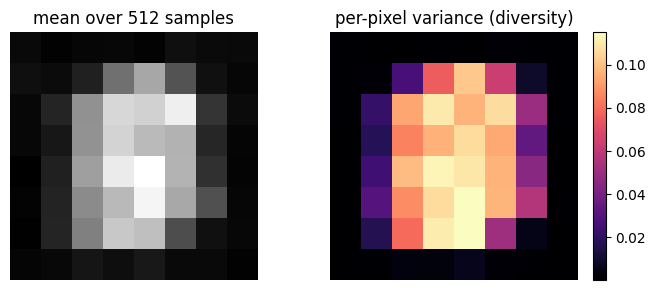

total sample variance (sum of per-pixel var): 2.578  (0 would mean collapse)


In [16]:
# Per-pixel variance across 512 seeds (diversity is measurable, not asserted).
big = ddpm_sample(512, seed=7)
var_map = big.var(0).reshape(IMG, IMG).cpu().numpy()
mean_map = big.mean(0).reshape(IMG, IMG).cpu().numpy()
fig, ax = plt.subplots(1,2, figsize=(7,3))
im0 = ax[0].imshow(mean_map, cmap="gray"); ax[0].set_title("mean over 512 samples"); ax[0].axis("off")
im1 = ax[1].imshow(var_map, cmap="magma"); ax[1].set_title("per-pixel variance (diversity)"); ax[1].axis("off")
plt.colorbar(im1, ax=ax[1], fraction=0.046); plt.tight_layout(); plt.show()
print(f"total sample variance (sum of per-pixel var): {var_map.sum():.3f}  (0 would mean collapse)")

### 4.5 The modern diffusion family (why vanilla DDPM is only the start)

Vanilla ancestral DDPM needs hundreds–thousands of network calls. The field moved on; the essentials:

- **DDIM** (implemented above): reinterprets the same trained $\epsilon_\theta$ as a *deterministic* ODE-like sampler on a subsequence of steps → 10–50 steps with little quality loss. Also gives a meaningful latent space (fixed noise ↔ fixed image).
- **Latent diffusion (Stable Diffusion)**: run diffusion in a pretrained autoencoder's *latent* space, not pixels. Cheaper and higher-res; diffusion models the compressed code, a decoder renders pixels.
- **Flow matching / rectified flow**: instead of a noising Markov chain, learn a velocity field $v_\theta(x,t)$ transporting noise to data along (nearly) straight paths, trained by regressing to a simple conditional target. Straighter paths ⇒ fewer sampling steps; this underlies several current SOTA systems.
- **Consistency models**: distill/train a network that maps *any* point on a trajectory directly to its endpoint, enabling **1–4 step** generation.

The through-line: they all learn something equivalent to the score / a probability-flow transport, then differ in the *path* and the *sampler*. The $\epsilon$-prediction loss you trained above is the common ancestor.

## Part 5 — Comparing the objectives *quantitatively*

We now put VAE, GAN, and DDPM samples on the same footing with two sample-based metrics (the only fair option, since a GAN has no likelihood):

1. **Class entropy** — feed generated images to a classifier trained on real data, histogram predicted classes, compute $H=-\sum_i p_i\log p_i$. High = balanced coverage; low = mode collapse.
2. **Fréchet feature distance (FD)** — an FID-analogue. Using the classifier's penultimate features, fit Gaussians to real and generated features and compute
$$\text{FD}=\|\mu_r-\mu_g\|^2+\operatorname{Tr}\!\big(\Sigma_r+\Sigma_g-2(\Sigma_r\Sigma_g)^{1/2}\big).$$
Lower = generated feature statistics match real. (We use our own small classifier, not InceptionV3, so absolute numbers aren't comparable to published FID — but *relative* comparisons here are meaningful.)

First, train the classifier and define the metrics.

In [17]:
# Small classifier on real data -> gives us both class predictions and features.
class Clf(nn.Module):
    def __init__(self, dim=DIM, hidden=256, nclass=10):
        super().__init__()
        self.feat = nn.Sequential(nn.Linear(dim, hidden), nn.ReLU(),
                                   nn.Linear(hidden, hidden), nn.ReLU())
        self.head = nn.Linear(hidden, nclass)
    def features(self, x): return self.feat(x)
    def forward(self, x): return self.head(self.feat(x))

NCLASS = int(y_all.max().item()) + 1
clf = Clf(nclass=NCLASS).to(device)
opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
Xc = X_all.reshape(len(X_all), -1)
for ep in range(30 if QUICK else 60):
    idx = torch.randperm(len(Xc))
    for i in range(0, len(Xc), 256):
        b = idx[i:i+256]
        loss = F.cross_entropy(clf(Xc[b]), y_all[b])
        opt.zero_grad(); loss.backward(); opt.step()
with torch.no_grad():
    acc = (clf(Xc).argmax(1) == y_all).float().mean().item()
print(f"classifier train accuracy: {acc:.3f}")

from scipy.linalg import sqrtm
def frechet_distance(real_imgs, gen_imgs):
    with torch.no_grad():
        fr = clf.features(real_imgs).cpu().numpy()
        fg = clf.features(gen_imgs).cpu().numpy()
    mr, mg = fr.mean(0), fg.mean(0)
    Cr = np.cov(fr, rowvar=False); Cg = np.cov(fg, rowvar=False)
    covmean = sqrtm(Cr @ Cg)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return float(((mr-mg)**2).sum() + np.trace(Cr + Cg - 2*covmean))

def class_entropy(gen_imgs):
    with torch.no_grad():
        p = clf(gen_imgs).softmax(1).mean(0).cpu().numpy()
    p = p[p > 0]
    return float(-(p*np.log(p)).sum())
print("max entropy (uniform):", math.log(NCLASS))

classifier train accuracy: 0.946
max entropy (uniform): 2.302585092994046


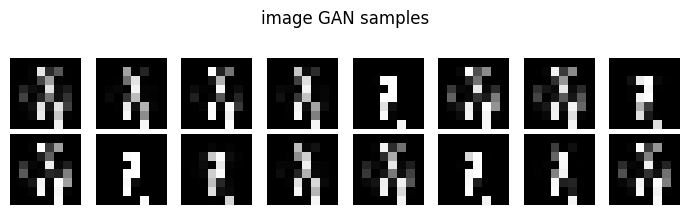

In [18]:
# Train a small IMAGE GAN so all three families are comparable on the SAME data.
Gi = nn.Sequential(nn.Linear(16,256), nn.ReLU(), nn.Linear(256,256), nn.ReLU(),
                   nn.Linear(256,DIM), nn.Sigmoid()).to(device)
Di = nn.Sequential(nn.Linear(DIM,256), nn.LeakyReLU(0.2), nn.Linear(256,256), nn.LeakyReLU(0.2),
                   nn.Linear(256,1)).to(device)
oG = torch.optim.Adam(Gi.parameters(), lr=2e-4, betas=(0.5,0.999))
oD = torch.optim.Adam(Di.parameters(), lr=2e-4, betas=(0.5,0.999))
bce = nn.BCEWithLogitsLoss()
Xg = X_all.reshape(len(X_all), -1)
git = 5000 if QUICK else 12000
torch.manual_seed(SEED)
for it in range(git):
    b = torch.randint(0, len(Xg), (256,), device=device)
    xr = Xg[b]; z = torch.randn(256,16, device=device)
    xf = Gi(z).detach()
    oD.zero_grad()
    ld = bce(Di(xr), torch.ones(256,1,device=device)) + bce(Di(xf), torch.zeros(256,1,device=device))
    ld.backward(); oD.step()
    z = torch.randn(256,16, device=device)
    oG.zero_grad(); lg = bce(Di(Gi(z)), torch.ones(256,1,device=device)); lg.backward(); oG.step()
with torch.no_grad():
    gan_imgs = Gi(torch.randn(1000,16, device=device))
show_grid(gan_imgs[:16], nrow=8, title="image GAN samples", figsize=(7,2.2))

model   FD (lower better)  class-entropy
REAL                0.912          2.292   <- reference
VAE                37.443          1.604
GAN                93.397          1.473
DDPM                7.672          2.153


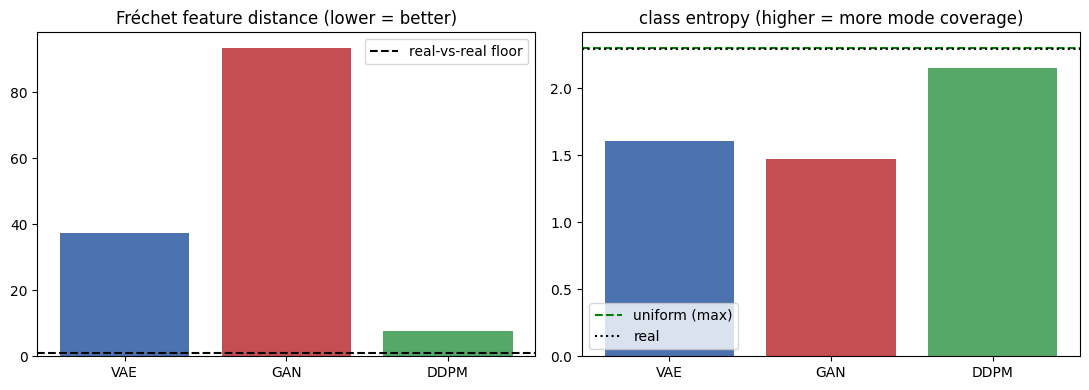

In [19]:
# Collect 1000 samples from each family and score them identically.
Nc = 1000
real = X_all.reshape(len(X_all),-1)[torch.randperm(len(X_all))[:Nc]]
with torch.no_grad():
    vae_imgs = torch.sigmoid(vae.decode(torch.randn(Nc,2, device=device)))   # sample prior -> decode
ddpm_imgs = ddpm_sample(Nc, seed=123)
gan_imgs = Gi(torch.randn(Nc,16, device=device))

models = {"VAE": vae_imgs, "GAN": gan_imgs, "DDPM": ddpm_imgs}
rows = []
for name, imgs in models.items():
    rows.append((name, frechet_distance(real, imgs), class_entropy(imgs)))
fd_real = frechet_distance(real, X_all.reshape(len(X_all),-1)[torch.randperm(len(X_all))[:Nc]])
ent_real = class_entropy(real)

print(f"{'model':6s} {'FD (lower better)':>18s} {'class-entropy':>14s}")
print(f"{'REAL':6s} {fd_real:18.3f} {ent_real:14.3f}   <- reference")
for name, fd, ent in rows:
    print(f"{name:6s} {fd:18.3f} {ent:14.3f}")

fig, ax = plt.subplots(1,2, figsize=(11,4))
names = [r[0] for r in rows]
ax[0].bar(names, [r[1] for r in rows], color=["#4c72b0","#c44e52","#55a868"])
ax[0].axhline(fd_real, ls="--", color="k", label="real-vs-real floor"); ax[0].legend()
ax[0].set_title("Fréchet feature distance (lower = better)")
ax[1].bar(names, [r[2] for r in rows], color=["#4c72b0","#c44e52","#55a868"])
ax[1].axhline(math.log(NCLASS), ls="--", color="green", label="uniform (max)")
ax[1].axhline(ent_real, ls=":", color="k", label="real")
ax[1].set_title("class entropy (higher = more mode coverage)"); ax[1].legend()
plt.tight_layout(); plt.show()

### Reading the comparison (and its caveats)

- Interpret **relative**, not absolute, numbers: the FD floor is the real-vs-real value (a fresh real sample vs another real sample); no model can beat it.
- On these tiny MLPs (8×8 or 32×32 depending on `QUICK`), expect: **VAE** — decent FD, tends to *lower* entropy only if the aggregated-posterior holes hurt sampling; samples look smooth/blurry (Part 1.4). **GAN** — can have sharp samples but is the one prone to *low entropy* (mode collapse, Part 2). **DDPM** — usually the best coverage (entropy near real) at the cost of many sampling steps.
- Results vary with seed and the `QUICK` budget — that variance is itself the point of Part 2's instability discussion. Rerun with `QUICK=False` for cleaner separation.

The headline: because a GAN has no likelihood, *sample-based* metrics are the only common yardstick — and they turn vague claims ("sharper", "more diverse", "collapsed") into numbers.

## Appendix — Common misconceptions (each debunked by a cell above)

1. **"All generative models are just noise→image maps."** They commit to different objects: a likelihood model (VAE), an implicit sampler with *no* density (GAN), and a reverse stochastic process (DDPM). — *Part 0.*
2. **"The ELBO is a heuristic."** It is an *exact* decomposition $\log p_\theta(x)=\mathcal L(x)+D_{\mathrm{KL}}(q_\phi\|p_\theta(z\mid x))$; the "bound" is just KL ≥ 0. — *Part 1.2.*
3. **"KL just keeps latent space tidy."** It regularizes each posterior *individually*; the **aggregated** posterior can still mismatch the prior, creating **holes** you sample from at generation time. — *Part 1.3.*
4. **"L2 causes blur (somehow)."** A Gaussian-mean decoder is Bayes-optimal at $\mathbb E[x\mid z]$; under multimodal uncertainty that is literally the average of the modes. Demonstrated on a bimodal target where the fit provably sits between the modes. — *Part 1.4.*
5. **"GAN = forger vs detective, the end."** At $D^\star$ the generator minimizes $2\,\mathrm{JS}(p_{\text{data}}\|p_g)-\log4$; disjoint supports ⇒ vanishing gradients, and nothing penalizes dropped modes. — *Part 2.1.*
6. **"You can eyeball mode collapse."** Better to *measure* it: mode-assignment entropy and coverage over training. — *Part 2.2.*
7. **"Predicting noise is a trick."** It equals learning the score $\nabla_x\log p$ of the noised data (up to $-1/\sigma$). — *Part 3.*
8. **"The DDPM closed form is just stated."** Derived by induction and **verified** by matching a simulated chain's mean/variance. — *Part 4.1.*
9. **"Predicting $\epsilon$ vs $x_0$ vs $v$ are different models."** They are interchangeable reparameterizations given $(x_t,t)$ (verified to numerical precision); the difference is loss *scaling*/stability. — *Part 4.2.*
10. **"DDPM is the state of the art."** It's the foundation; DDIM, latent diffusion, flow matching / rectified flow, and consistency models dominate now. — *Part 4.5.*
11. **"Just look at the samples."** Since a GAN has no likelihood, compare families with sample-based metrics (class entropy, Fréchet feature distance). — *Part 5.*

***
*`QUICK=False` uses 32×32 digits; `QUICK=True` uses 8×8 for a fast CPU run. For full 28×28 MNIST + conv nets, change `IMG` and the model classes.*